In [7]:
import pandas as pd 
df = pd.read_csv("train.csv")
display(df.head());
print(df.shape)

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


(668665, 15)


In [11]:
df.describe()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level
count,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000
mean,334332.000000,47.039171,84769.266989,32.158298,1.712626,4.960408,7.176314,2.935477
std,193027.103211,12.875448,28648.029042,18.730474,0.729275,3.926843,5.186627,1.429119
min,0.000000,25.000000,30000.000000,5.000000,1.000000,0.000000,0.000000,1.000000
25%,167166.000000,36.000000,67376.000000,17.200000,1.000000,2.000000,3.000000,2.000000
50%,334332.000000,47.000000,84880.000000,33.600000,2.000000,4.000000,6.000000,3.000000
75%,501498.000000,58.000000,102753.000000,47.400000,2.000000,7.000000,10.000000,4.000000
max,668664.000000,69.000000,188549.000000,98.700000,4.000000,14.000000,19.000000,5.000000


In [16]:
df.drop("id", axis=1)

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,30,71090.0,27.4,2,5,6,5.0,Male,Urban,Sedan,No,Yes,Medium,No
668661,32,129990.0,5.0,2,5,4,1.0,Female,Suburban,SUV,Yes,Yes,Low,No
668662,64,121791.0,24.2,1,5,6,1.0,Female,Suburban,Hatchback,Yes,Yes,Low,No
668663,51,115923.0,43.7,2,0,0,1.0,Female,Rural,SUV,Yes,Yes,Low,No


In [17]:
df.dtypes

id                               int64
Age                              int64
Annual_Income_USD              float64
Daily_Commute_km               float64
Number_of_Cars_Owned             int64
Charging_Stations_Near_Home      int64
Charging_Stations_Near_Work      int64
Environmental_Concern_Level    float64
Gender                             str
City_Type                          str
Current_Car_Type                   str
Home_Charging_Possible             str
Subsidy_Available                  str
Range_Anxiety_Level                str
Will_Buy_EV                        str
dtype: object

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# X = df.drop(columns=["Will_Buy_EV"])
# y = df["Will_Buy_EV"]

X = pd.get_dummies(df.drop(columns=["Will_Buy_EV", "id"]), drop_first=True)
y = df["Will_Buy_EV"].map({"Yes": 1, "No": 0})

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

pred = model.predict_proba(X_valid)[:, 1]

print(roc_auc_score(y_valid, pred))

0.9049490403179132


c:\Users\Kamlesh Singh\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


* Now let's try to perform standardization here as 6 of the columns are categorical.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

pred = model.predict_proba(X_valid)[:, 1]

print(roc_auc_score(y_valid, pred))

0.9383594196482687


* Accuracy Improved from 0.90 to 0.93
## Let's try using XGBoost now

In [27]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

X = pd.get_dummies(df.drop(columns=["Will_Buy_EV", "id"]), drop_first=True)
y = df["Will_Buy_EV"].map({"Yes": 1, "No": 0})

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict_proba(X_valid)[:, 1]

print(roc_auc_score(y_valid, pred))

0.9416971171284898


* Reached 0.90 Accuracy -> 0.93 (Using Standardization) -> 0.94 (Using XGBoost)
* Let's try CatBoost now :

In [29]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score

model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    random_seed=42,
    verbose=False
)

model.fit(X_train, y_train)

pred = model.predict_proba(X_valid)[:, 1]

print(roc_auc_score(y_valid, pred))

0.9408775746452015


* CatBoost reaches a 0.0008 lower accuracy than XGBoost, which is insignificant in hindsight.
* Before moving forward let's try plotting some graphs or subplots and check out how the data is distributed.

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


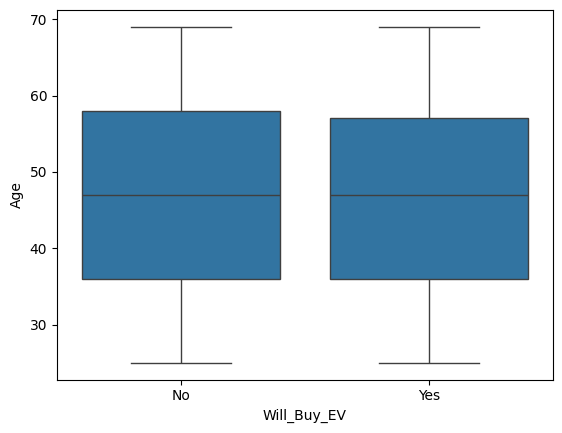

In [32]:
%pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x="Will_Buy_EV", y="Age")
plt.show()

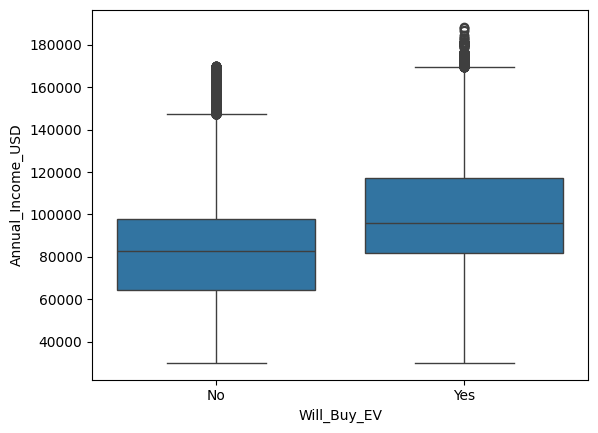

In [33]:
sns.boxplot(data=df, x="Will_Buy_EV", y="Annual_Income_USD")
plt.show()

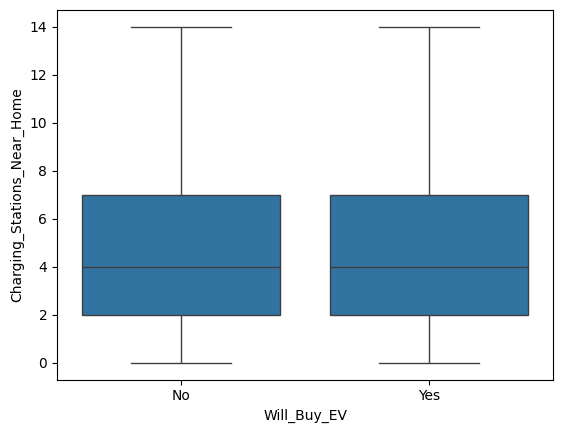

In [34]:
sns.boxplot(
    data=df,
    x="Will_Buy_EV",
    y="Charging_Stations_Near_Home"
)
plt.show()

* Plots really didn't tell me anything, the dataset is pretty evenly distributed apart from the fact that low-mid earning individuals don't prefer purchasing EV's.
* Let's try to get into more detail for this using some plots.

In [37]:
pd.crosstab(
    pd.qcut(df["Annual_Income_USD"], 5),
    df["Will_Buy_EV"],
    normalize="index"
)

Will_Buy_EV,No,Yes
Annual_Income_USD,,
"(29999.999, 62671.0]",0.935472,0.064528
"(62671.0, 78915.0]",0.880863,0.119137
"(78915.0, 91619.0]",0.832084,0.167916
"(91619.0, 107798.0]",0.791369,0.208631
"(107798.0, 188549.0]",0.686862,0.313138


In [38]:
df.groupby("Will_Buy_EV")["Annual_Income_USD"].mean()

Will_Buy_EV
No     81794.588556
Yes    98827.302948
Name: Annual_Income_USD, dtype: float64

* Income feels highly predictive of the final result now, it keeps increasing as we go up and seems the strongest feature in our dataframe.

<Axes: xlabel='Will_Buy_EV', ylabel='Annual_Income_USD'>

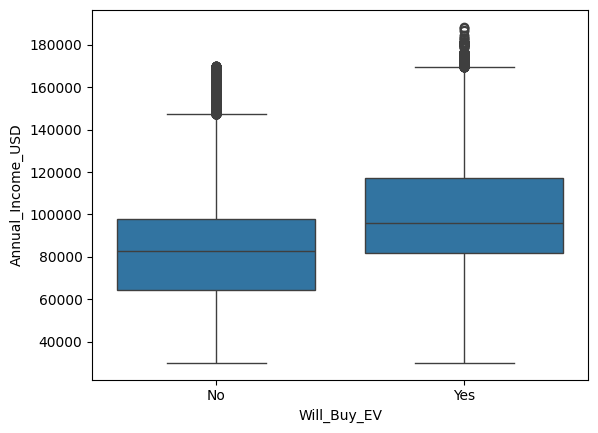

In [39]:
sns.boxplot(data=df, x="Will_Buy_EV", y="Annual_Income_USD")

In [45]:
pd.crosstab(df["Subsidy_Available"], df["Will_Buy_EV"], normalize="index")

Will_Buy_EV,No,Yes
Subsidy_Available,,
No,0.994243,0.005757
Yes,0.725305,0.274695


* We've just realized, subsidy available is a incredibly strong feature as well, maybe even stronger than Income.
* Let's try to build and train our better baseline model now

In [46]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
y = train["Will_Buy_EV"].map({"No": 0, "Yes": 1}) # just binary classification 
X = train.drop(columns=["Will_Buy_EV"])
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    verbose=50,
    random_seed=42
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_cols
)

predictions = model.predict_proba(X_valid)[:, 1]
score = roc_auc_score(y_valid, predictions)
print("ROC-AUC:", score)

C:\Users\Kamlesh Singh\AppData\Local\Temp\ipykernel_1260\1621316614.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object"]).columns.tolist()


ROC-AUC: 0.9410673370250272


* Okay 0.941 is good enough for my first proper baseline model, the leaderboard top is 0.946 so I'm far by 0.005.
* Let's make this submission and then try newer techniques later.

In [47]:
# Preparing a submission.csv for submission now.
test_predictions = model.predict_proba(test)[:, 1]
submission = pd.DataFrame({
    "id": test["id"],
    "Will_Buy_EV": test_predictions
})
submission.to_csv("submission.csv", index=False)
print(submission.head())
print(submission.shape)

       id  Will_Buy_EV
0  668665     0.015709
1  668666     0.021093
2  668667     0.004566
3  668668     0.002883
4  668669     0.022438
(286571, 2)


* Let's run k-fold now on the training dataset and then check results and optimize the hyperparameters.


In [ ]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier

train = pd.read_csv("train.csv")

y = train["Will_Buy_EV"].map({"No": 0, "Yes": 1})
X = train.drop(columns=["Will_Buy_EV"])

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []

for fold, (train_idx, valid_idx) in enumerate(kf.split(X, y), 1):
    X_train = X.iloc[train_idx]
    X_valid = X.iloc[valid_idx]
    y_train = y.iloc[train_idx]
    y_valid = y.iloc[valid_idx]

    model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        verbose=False,
        random_seed=42
    )

    model.fit(
        X_train,
        y_train,
        cat_features=cat_cols
    )

    predictions = model.predict_proba(X_valid)[:, 1]
    score = roc_auc_score(y_valid, predictions)

    scores.append(score)

    print(f"Fold {fold}: {score:.6f}")

print("\nMean ROC-AUC:", sum(scores) / len(scores))
print("Std ROC-AUC:", pd.Series(scores).std())

C:\Users\Kamlesh Singh\AppData\Local\Temp\ipykernel_1260\3607499962.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object"]).columns.tolist()


Fold 1: 0.939997
Fold 2: 0.940999
Fold 3: 0.942206
Fold 4: 0.941849
